In [2]:
from pathlib import Path
import os
import shutil
from tqdm.notebook import tqdm
import json
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import zarr
import nibabel as nib
from skimage.filters import frangi , hessian , meijering
import SimpleITK as sitk

In [3]:
root_raw_folder = "."
root_out_folder = "./dataset" # Dataset774_CAD

raw_annot_postfix = "processed"

syntax_mapings = [
    '1', '2', '3', '4', '5', 
    '6', '9', '7', '9a', '10', 
    '8', '10a', '12', '11', '12a', 
    '12b', '13', '14', '14a', '14b', 
    '15', '16', '16a', '16b', '16c'
]
class_map = {
        1: '1',2: '2', 3: '3',4: '4',
        5: '5',6: '6',7: '7',8: '8',
        9: '9',10: '9a',11: '10',12: '10a',
        13: '11',14: '12',15: '12a',16: '13',
        17: '14',18: '14a',19: '15',20: '16',
        21: '16a',22: '16b',23: '16c',
        24: '12b',25: '14b'
    }
reversed_map = {
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6': 6,
    '9': 7,
    '7': 8,
    '9a': 9,
    '10': 10,
    '8': 11,
    '10a': 12,
    '12': 13,
    '11': 14,
    '12a': 15,
    '12b': 16,
    '13': 17,
    '14': 18,
    '14a': 19,
    '14b': 20,
    '15': 21,
    '16': 22,
    '16a': 23,
    '16b': 24,
    '16c': 25
}
stenosis_mappings = [
    'stenosis'
]

In [4]:
# Path(root_out_folder).mkdir(parents=True, exist_ok=True)

In [5]:
# train_imgs = os.listdir("./nnUnet_dataset/syntax/images/train/")
# valid_imgs = os.listdir("./nnUnet_dataset/syntax/images/val/")
# train_labels = os.listdir("./nnUnet_dataset/syntax/labels/train/")
# for train_path in tqdm(train_imgs):
#     name = (train_path.split("/")[-1]).split(".")[0]
#     prefix = "0"*(4-len(name))
#     name = prefix + name
#     img = cv2.imread(os.path.join("./nnUnet_dataset/syntax/images/train/",train_path), cv2.IMREAD_GRAYSCALE)
#     nii = nib.Nifti1Image(img, affine=np.eye(4, dtype=np.float32))
#     nib.save(nii, f"./nnUnet_Official_dataset/Dataset774_CAD/imagesTr/{name}_0000.nii.gz")

    # img = cv2.imread(os.path.join("./nnUnet_dataset/syntax/images/train/",train_path),cv2.IMREAD_GRAYSCALE)
    # img_itk = sitk.GetImageFromArray(img.astype(np.float32))
    # name = (train_path.split("/")[-1]).split(".")[0]
    # prefix = "0"*(4-len(name))
    # name = prefix + name
    # sitk.WriteImage(img_itk, f"nnUnet_Official_dataset/Dataset774_CAD/imagesTr/{name}_0000.nii.gz", useCompression=True)

In [6]:
# for val_path in tqdm(valid_imgs):
#     name = (val_path.split("/")[-1]).split(".")[0]
#     prefix = "0"*(4-len(name))
#     name = prefix + name
#     img = cv2.imread(os.path.join("./nnUnet_dataset/syntax/images/val/",val_path), cv2.IMREAD_GRAYSCALE)
#     nii = nib.Nifti1Image(img, affine=np.eye(4, dtype=np.float32))
#     nib.save(nii, f"./nnUnet_Official_dataset/Dataset774_CAD/imagesTs/{name}_0000.nii.gz")

    # cv2.imwrite(f"./nnUnet_Official_dataset/Dataset774_CAD/imagesTs/{name}_0000.png", img)

    # img = cv2.imread(os.path.join("./nnUnet_dataset/syntax/images/val/",val_path),cv2.IMREAD_GRAYSCALE)
    # img_itk = sitk.GetImageFromArray(img.astype(np.float32))
    # name = (val_path.split("/")[-1]).split(".")[0]
    # prefix = "0"*(4-len(name))
    # name = prefix + name
    # sitk.WriteImage(img_itk, f"nnUnet_Official_dataset/Dataset774_CAD/imagesTs/{name}_0000.nii.gz", useCompression=True)

In [7]:
# for label_path in tqdm(train_labels):
#     label = zarr.load(os.path.join("./nnUnet_dataset/syntax/labels/train/", label_path))
#     label = np.where(label == 25, 0, label + 1)
#     label = label.astype(np.uint8)

#     name = (label_path.split("/")[-1]).split(".")[0]
#     prefix = "0"*(4-len(name))
#     name = prefix + name

#     nii = nib.Nifti1Image(label, affine=np.eye(4, dtype=np.float32))
#     nib.save(nii, f"nnUnet_Official_dataset/Dataset774_CAD/labelsTr/{name}.nii.gz")

In [8]:
def polygons_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)
    
    for poly in segmentation:
        pts = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        draw.polygon(pts, outline=1, fill=1)
    return np.array(mask, dtype=np.uint8)
def make_binary_image (labels,segments,revereversed_map,class_map,W,H):
    binary_image = np.zeros((H,W))
    for i,label in enumerate(labels):
        mask = polygons_to_mask([segments[i]],W,H)
        new_label = revereversed_map[class_map[label+1]]
        binary_image[mask==1] = new_label
    binary_image = binary_image.astype(np.uint8)
    return binary_image

In [9]:
class CLAHE : 
    def __init__(self,clipLimit=2.0,tileGridSize=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    def __call__(self,img):
        enhanced = np.clip(img, 0, 255)
        return self.clahe.apply(enhanced)
class WhiteTopHat:
    def __init__(self,kernel_size = (50, 50),turn_neg = True):
        self.kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
        self.turn_neg = turn_neg
    def __call__(self,img):
        neg_img = cv2.bitwise_not(img)
        tophat_img = cv2.morphologyEx(neg_img, cv2.MORPH_TOPHAT, self.kernel,borderType=cv2.BORDER_REPLICATE)
        # tophat_img = morphology.white_tophat(neg_img, self.kernel) 
        return cv2.subtract(img, tophat_img)

In [10]:
def create_string_labels(bboxes, labels):
    ls = []
    for i, l in enumerate(labels):
        if int(l) == 25:
            l = 0
        bboxes[i] = [l] + bboxes[i]
        label, cx, cy, w, h = bboxes[i]
        ls.append(f'{label} {cx} {cy} {w} {h}')
    return "\n".join(ls)

def create_string_segments(segmentation, bboxes, labels, W, H):
    ls = []
    for i, l in enumerate(labels):
        if int(l) == 25:
            l = 0
        segment = segmentation[i]
        segment = [str(segment[j] / 512) for j in range(len(segment))]
        segment = [str(l)] + segment
        ls.append(" ".join(segment))
    return "\n".join(ls)


def _process_one(item, *, part, method,
                 out_img_folder_path, out_seg_folder_path, out_annot_folder_path,out_prep_folder_path,out_transformed_path,reversed_map,class_map,transforms=None):

    img_path, data = item
    img_name = os.path.splitext(os.path.basename(img_path))[0]

    bboxes = data["bbox_yolo"]
    labels = data["labels"]
    seg = data["segmentation"]
    W = data["W"]
    H = data["H"]
    # print(transforms)
    shutil.copyfile(img_path, os.path.join(out_img_folder_path, f"{img_name}.png"))
    if method == "seg":
        str_segments = create_string_segments(seg, bboxes, labels, W, H)
        seg_path = os.path.join(out_seg_folder_path, f"{img_name}.txt")
        with open(seg_path, "w") as f:
            f.write(str_segments)

    elif method == "detect":
        str_labels = create_string_labels(bboxes, labels)
        annot_path = os.path.join(out_annot_folder_path, f"{img_name}.txt") 
        with open(annot_path, "w") as f:
            f.write(str_labels)

    elif method == "seg-binary":
        binary_img = make_binary_image(labels, seg,reversed_map,class_map, W, H)
        seg_path = os.path.join(out_seg_folder_path, f"{img_name}.zarr")
        img = cv2.imread(os.path.join(out_img_folder_path, f"{img_name}.png"),cv2.IMREAD_GRAYSCALE)
        
        zarr.save(seg_path, binary_img)
        if(transforms is not None):
            
            img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
            out_binary_path = os.path.join(out_prep_folder_path,f"{img_name}.png")
            for t in transforms:
                img = t(img)
            cv2.imwrite(out_binary_path,img)

    else:
        raise ValueError("method not found")

    return img_name

def create_dataset(task, parts=("train", "val", "test"), method="seg",
                   parallel=True, executor="process", max_workers=None,transforms=None):
    
    out_image_folder_path = os.path.join(root_out_folder, task, "images")
    out_label_folder_path = os.path.join(root_out_folder, task, "labels")
    out_preprocessed_folder_path = os.path.join(root_out_folder, task, "preprocessed")
    out_transformed_folder_path = os.path.join(root_out_folder, task, "transformed")
    out_segement_folder_path = out_label_folder_path  # keeping your pathing

    task_folder_path = os.path.join(root_raw_folder, task)
    annot_folder_path = os.path.join(root_raw_folder, f"{task}-{raw_annot_postfix}")

    if os.path.exists(out_label_folder_path):
        shutil.rmtree(out_label_folder_path)

    if os.path.exists(out_transformed_folder_path):
        shutil.rmtree(out_transformed_folder_path)

    Path(out_image_folder_path).mkdir(parents=True, exist_ok=True)
    Path(out_label_folder_path).mkdir(parents=True, exist_ok=True)
    Path(out_preprocessed_folder_path).mkdir(parents=True,exist_ok=True)
    Path(out_transformed_folder_path).mkdir(parents=True,exist_ok=True)
    for part in parts:
        print(f"[{task}] {part}")

        in_image_folder_path = os.path.join(task_folder_path, part, "images")
        in_annot_folder_path = os.path.join(annot_folder_path, f"{part}.json")

        out_annot_folder_path = os.path.join(out_label_folder_path, part)
        out_seg_folder_path = os.path.join(out_segement_folder_path, part)
        out_img_folder_path = os.path.join(out_image_folder_path, part)
        out_prep_folder_path = os.path.join(out_preprocessed_folder_path, part)
        out_trans_folder_path =  os.path.join(out_transformed_folder_path, part)

        Path(out_annot_folder_path).mkdir(parents=True, exist_ok=True)
        Path(out_seg_folder_path).mkdir(parents=True, exist_ok=True)
        Path(out_img_folder_path).mkdir(parents=True, exist_ok=True)
        Path(out_prep_folder_path).mkdir(parents=True, exist_ok=True)
        Path(out_trans_folder_path).mkdir(parents=True,exist_ok=True)
        with open(in_annot_folder_path, "r") as f:
            annot_file = json.load(f)

        items = list(annot_file.items())
        
        if not parallel:
            
            for item in tqdm(items):
                _process_one(
                    item,
                    part=part,
                    method=method,
                    out_img_folder_path=out_img_folder_path,
                    out_seg_folder_path=out_seg_folder_path,
                    out_annot_folder_path=out_annot_folder_path,
                    out_prep_folder_path = out_prep_folder_path,
                    out_transformed_path = out_trans_folder_path,
                    transforms=transforms
                )
        else:
            
            Executor = ProcessPoolExecutor if executor == "process" else ThreadPoolExecutor
            with Executor(max_workers=max_workers) as pool:
                
                futures = [
                    pool.submit(
                        _process_one,
                        item,
                        part=part,
                        method=method,
                        out_img_folder_path=out_img_folder_path,
                        out_seg_folder_path=out_seg_folder_path,
                        out_annot_folder_path=out_annot_folder_path,
                        out_prep_folder_path = out_prep_folder_path,
                        out_transformed_path = out_trans_folder_path,
                        transforms=transforms,
                        reversed_map = reversed_map,
                        class_map = class_map
                    )
                    for item in items
                ]
                for f in tqdm(as_completed(futures), total=len(futures)):
                    try:
                        f.result()
                    except Exception as e:
                        print("Worker failed:", repr(e))
                    
    l = syntax_mapings if task == "syntax" else stenosis_mappings
    with open(os.path.join(root_out_folder, f"{task}-classes"), "wb") as fp:
        pickle.dump(l, fp)
# transforms = [
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
# ]
transforms=None
create_dataset("syntax", method="seg-binary", parallel=True, executor="thread",transforms=transforms)


[syntax] train


  0%|          | 0/1000 [00:00<?, ?it/s]

[syntax] val


  0%|          | 0/200 [00:00<?, ?it/s]

[syntax] test


  0%|          | 0/300 [00:00<?, ?it/s]

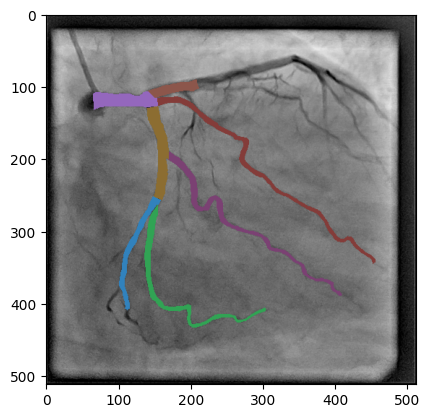

In [10]:
image = cv2.imread("./nnUnet_dataset/syntax/images/train/584.png",cv2.IMREAD_COLOR_RGB)
mask = zarr.load("./nnUnet_dataset/syntax/labels/train/584.zarr")

colors = np.array([
    (31, 119, 180),   # Blue
    (255, 127, 14),   # Orange
    (44, 160, 44),    # Green
    (214, 39, 40),    # Red
    (148, 103, 189),  # Purple
    (140, 86, 75),    # Brown
    (227, 119, 194),  # Pink
    (127, 127, 127),  # Gray
    (188, 189, 34),   # Yellow-green
    (23, 190, 207),   # Cyan
    (57, 59, 121),    # Navy
    (99, 121, 57),    # Olive
    (140, 109, 49),   # Gold
    (132, 60, 57),    # Maroon
    (123, 65, 115),   # Violet
    (49, 130, 189),   # Sky Blue
    (49, 163, 84),    # Lime
    (230, 85, 13),    # Bright Orange
    (117, 107, 177),  # Medium Purple
    (99, 99, 99),     # Dark Gray
    (158, 202, 225),  # Light Blue
    (116, 196, 118),  # Light Green
    (253, 141, 60),   # Light Orange
    (231, 150, 156),  # Light Pink
    (199, 199, 199),  # Light Gray
], dtype=np.uint8)
args = {"class_count":26}
def draw_mask(image,mask,colors,args):
    class_count= args["class_count"]
    H,W,C=image.shape
    for i in range(H):
        for j in range(W):
            c = mask[i,j]
            if(c==0):
                continue
            image[i,j] = colors[c-1]
    plt.imshow(image)
# image.reshape(-1,3)
# colors[mask.reshape(-1)].shape
# image.shape
draw_mask(image,mask,colors,args)

In [11]:
Counter(mask.reshape(-1))

Counter({np.uint8(0): 249756,
         np.uint8(14): 2484,
         np.uint8(15): 2263,
         np.uint8(17): 2025,
         np.uint8(13): 1868,
         np.uint8(5): 1612,
         np.uint8(16): 1288,
         np.uint8(6): 848})